In [ ]:
# ================================================================
# PROYEK UAS DATA MINING - TUGAS FORECASTING
# ================================================================
# Mata Kuliah: Data Mining
# Topik: Peramalan Jumlah Penyewaan Motor
# ================================================================

# ================================================================
# KODE 1.1 - SETUP DAN INSTALASI LIBRARY
# ================================================================

# Instal library yang diperlukan
!pip install pmdarima statsmodels prophet -q

# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Setting visualisasi
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Semua library berhasil diinstall dan diimport!")

✅ Semua library berhasil diinstall dan diimport!


In [ ]:
# ================================================================
# KODE 2.1 - MEMUAT DAN MENDESKRIPSIKAN DATASET
# ================================================================

# Load dataset - SESUAIKAN PATH FILE ANDA
file_path = '/Data Penyewaan Motor Rapih - Data Penyewaan Motor Rapih.csv'
df = pd.read_csv(file_path)

# Informasi awal dataset
print("="*70)
print("INFORMASI AWAL DATASET")
print("="*70)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n5 Data Pertama:")
print(df.head())

print("\nInformasi Tipe Data:")
print(df.info())

print("\nStatistik Deskriptif:")
print(df.describe())

INFORMASI AWAL DATASET
Jumlah baris: 288
Jumlah kolom: 6

5 Data Pertama:
   Tanggal   Jenis_Motor  Unit_Tersedia Hari_Libur  Promo  Jumlah_Penyewaan
0  2019-01  Honda Scoopy             35         Ya  Tidak               189
1  2019-01    Honda Beat             40         Ya  Tidak               212
2  2019-01   Yamaha NMAX             30         Ya  Tidak               157
3  2019-01     Honda PCX             25         Ya  Tidak               140
4  2019-02  Honda Scoopy             35      Tidak     Ya               110

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Tanggal           288 non-null    object
 1   Jenis_Motor       288 non-null    object
 2   Unit_Tersedia     288 non-null    int64 
 3   Hari_Libur        288 non-null    object
 4   Promo             288 non-null    object
 5   Jumlah_Penyewaan 

In [ ]:
# ================================================================
# KODE 2.2 - AGREGASI DATA BULANAN
# ================================================================

# Konversi Tanggal ke format datetime (asumsi format YYYY-MM)
df['Tanggal'] = pd.to_datetime(df['Tanggal'] + '-01')

# Agregasi total penyewaan per bulan
monthly_rental = df.groupby('Tanggal')['Jumlah_Penyewaan'].sum().reset_index()
monthly_rental.columns = ['ds', 'y']  # Rename untuk Prophet

print("\n" + "="*70)
print("DATA AGREGASI BULANAN")
print("="*70)
print(monthly_rental.head(10))
print(f"\nRentang Waktu: {monthly_rental['ds'].min()} sampai {monthly_rental['ds'].max()}")
print(f"Total data point: {len(monthly_rental)} bulan")


DATA AGREGASI BULANAN
          ds    y
0 2019-01-01  698
1 2019-02-01  409
2 2019-03-01  401
3 2019-04-01  445
4 2019-05-01  445
5 2019-06-01  637
6 2019-07-01  810
7 2019-08-01  868
8 2019-09-01  445
9 2019-10-01  512

Rentang Waktu: 2019-01-01 00:00:00 sampai 2024-12-01 00:00:00
Total data point: 72 bulan


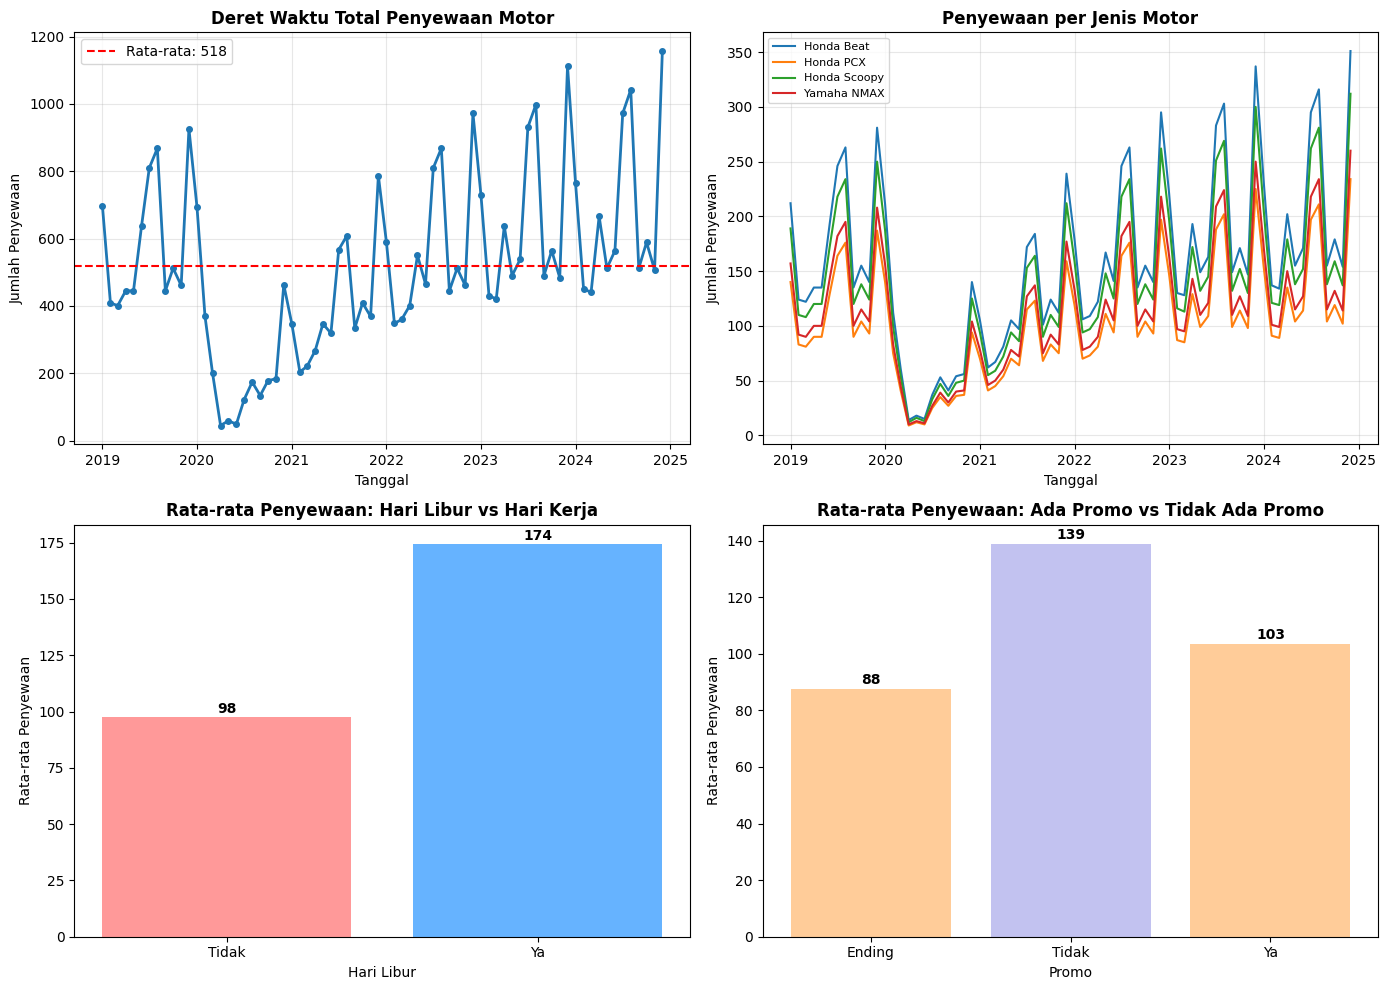

In [ ]:
# ================================================================
# KODE 3.1 - VISUALISASI DERET WAKTU DAN ANALISIS POLA
# ================================================================
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt
import seaborn as sns # Also imported in pfx7EhvYgJ6n, good to have it here too for plots

# Re-execute the necessary data preparation steps for 'df' and 'monthly_rental'
# to ensure they are correctly formatted and defined for this cell's execution.
# This addresses potential issues from kernel restarts or out-of-order execution
# that might lead to 'monthly_rental' not being defined or 'Tanggal' being the wrong type.

# Ensure 'Tanggal' in df is a datetime object, as it's modified in KODE 2.2
# and used by monthly_rental and other plots in this cell.
# Check if 'Tanggal' column exists and if it's not already datetime
if 'Tanggal' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Tanggal']):
    df['Tanggal'] = pd.to_datetime(df['Tanggal'].astype(str) + '-01')

# Create or re-create monthly_rental
monthly_rental = df.groupby('Tanggal')['Jumlah_Penyewaan'].sum().reset_index()
monthly_rental.columns = ['ds', 'y']  # Rename for Prophet

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Deret waktu total penyewaan
axes[0, 0].plot(monthly_rental['ds'], monthly_rental['y'],
                marker='o', linestyle='-', linewidth=2, markersize=4)
axes[0, 0].set_title('Deret Waktu Total Penyewaan Motor', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tanggal')
axes[0, 0].set_ylabel('Jumlah Penyewaan')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=monthly_rental['y'].mean(), color='red', linestyle='--',
                  label=f'Rata-rata: {monthly_rental["y"].mean():.0f}')
axes[0, 0].legend()

# Plot 2: Per jenis motor
motor_type = df.groupby(['Tanggal', 'Jenis_Motor'])['Jumlah_Penyewaan'].sum().reset_index()
for motor in motor_type['Jenis_Motor'].unique():
    subset = motor_type[motor_type['Jenis_Motor'] == motor]
    axes[0, 1].plot(subset['Tanggal'], subset['Jumlah_Penyewaan'],
                    label=motor, linewidth=1.5)
axes[0, 1].set_title('Penyewaan per Jenis Motor', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tanggal')
axes[0, 1].set_ylabel('Jumlah Penyewaan')
axes[0, 1].legend(loc='upper left', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Pengaruh Hari Libur
holiday_effect = df.groupby('Hari_Libur')['Jumlah_Penyewaan'].mean().reset_index()
colors = ['#ff9999', '#66b3ff']
axes[1, 0].bar(holiday_effect['Hari_Libur'], holiday_effect['Jumlah_Penyewaan'], color=colors)
axes[1, 0].set_title('Rata-rata Penyewaan: Hari Libur vs Hari Kerja', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hari Libur')
axes[1, 0].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(holiday_effect['Jumlah_Penyewaan']):
    axes[1, 0].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

# Plot 4: Pengaruh Promo
promo_effect = df.groupby('Promo')['Jumlah_Penyewaan'].mean().reset_index()
colors = ['#ffcc99', '#c2c2f0']
axes[1, 1].bar(promo_effect['Promo'], promo_effect['Jumlah_Penyewaan'], color=colors)
axes[1, 1].set_title('Rata-rata Penyewaan: Ada Promo vs Tidak Ada Promo', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Promo')
axes[1, 1].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(promo_effect['Jumlah_Penyewaan']):
    axes[1, 1].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

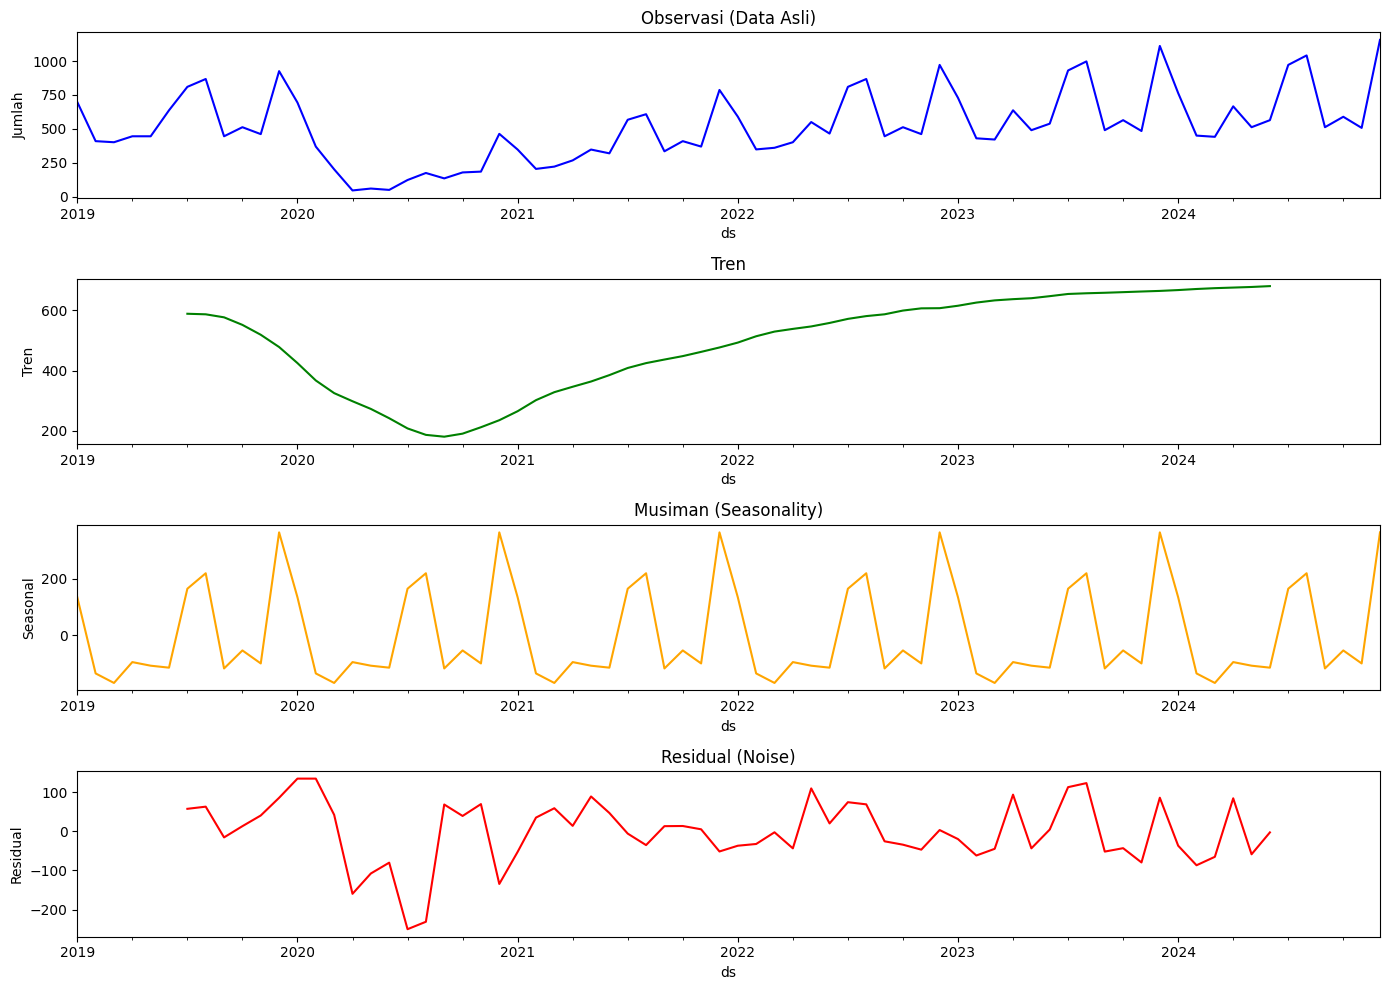

In [ ]:
# ================================================================
# KODE 3.2 - DEKOMPOSISI TIME SERIES
# ================================================================

from statsmodels.tsa.seasonal import seasonal_decompose

monthly_rental_indexed = monthly_rental.set_index('ds')
decomposition = seasonal_decompose(monthly_rental_indexed['y'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observasi (Data Asli)', color='blue')
axes[0].set_ylabel('Jumlah')
decomposition.trend.plot(ax=axes[1], title='Tren', color='green')
axes[1].set_ylabel('Tren')
decomposition.seasonal.plot(ax=axes[2], title='Musiman (Seasonality)', color='orange')
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)', color='red')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# KODE 4.1 - PENGEECEKAN STASIONERITAS DATA
# ================================================================
# Cek stasioneritas dengan Augmented Dickey-Fuller Test
def check_stationarity(timeseries, title=''):
    result = adfuller(timeseries, autolag='AIC')
    print(f'\nHasil Uji Dickey-Fuller (ADF) - {title}')
    print('='*50)
    print(f'ADF Statistik: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\n✅ Data STASIONER (tolak H0)")
    else:
        print("\n❌ Data TIDAK STASIONER (gagal tolak H0)")
        print("   Perlu dilakukan differencing")
    return result

# Cek stasioneritas data asli
check_stationarity(monthly_rental['y'], 'Data Asli')

# Differencing jika diperlukan
monthly_rental['y_diff1'] = monthly_rental['y'].diff()
monthly_rental['y_diff12'] = monthly_rental['y'].diff(12)

# Cek stasioneritas setelah differencing musiman
check_stationarity(monthly_rental['y_diff12'].dropna(), 'Data Setelah Differencing Musiman (lag 12)')



Hasil Uji Dickey-Fuller (ADF) - Data Asli
ADF Statistik: -1.6993
p-value: 0.4315
Critical Values:
	1%: -3.5464
	5%: -2.9119
	10%: -2.5937

❌ Data TIDAK STASIONER (gagal tolak H0)
   Perlu dilakukan differencing

Hasil Uji Dickey-Fuller (ADF) - Data Setelah Differencing Musiman (lag 12)
ADF Statistik: -1.7980
p-value: 0.3814
Critical Values:
	1%: -3.5464
	5%: -2.9119
	10%: -2.5937

❌ Data TIDAK STASIONER (gagal tolak H0)
   Perlu dilakukan differencing


(np.float64(-1.7980441453863925),
 np.float64(0.38143315259105603),
 0,
 59,
 {'1%': np.float64(-3.5463945337644063),
  '5%': np.float64(-2.911939409384601),
  '10%': np.float64(-2.5936515282964665)},
 np.float64(565.8091014481366))


PEMBAGIAN DATA KRONOLOGIS
Train data: 57 bulan (2019-01-01 00:00:00 s.d. 2023-09-01 00:00:00)
Test data: 15 bulan (2023-10-01 00:00:00 s.d. 2024-12-01 00:00:00)

Rasio train:test = 57:15 (79.2%:20.8%)


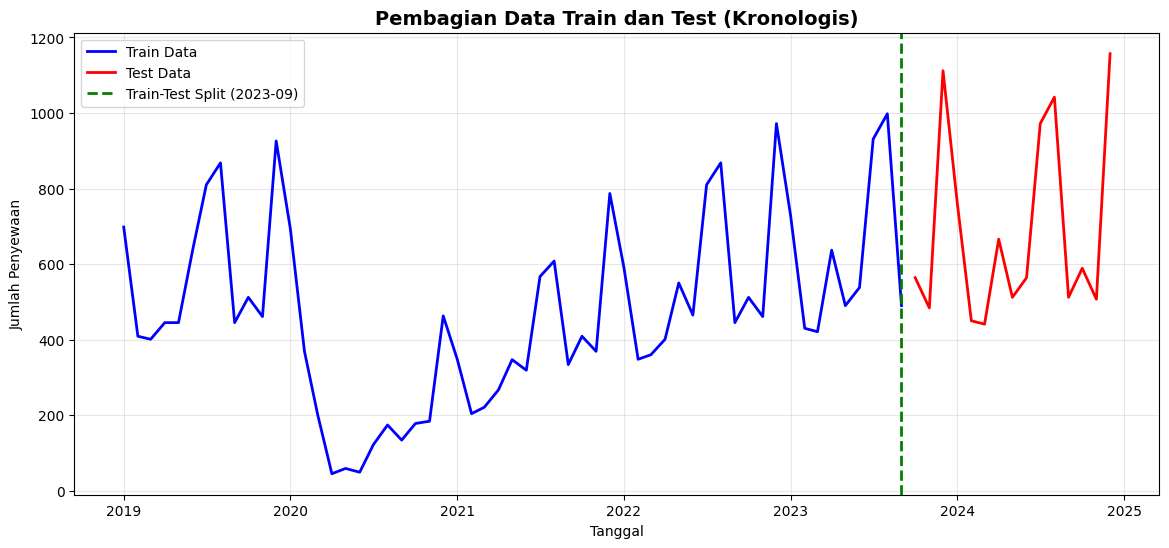

In [ ]:
# ================================================================
# KODE 4.2 - PEMBAGIAN DATA SECARA KRONOLOGIS
# ================================================================

train_size = int(len(monthly_rental) * 0.8)
train_data = monthly_rental.iloc[:train_size].copy()
test_data = monthly_rental.iloc[train_size:].copy()

print("\n" + "="*70)
print("PEMBAGIAN DATA KRONOLOGIS")
print("="*70)
print(f"Train data: {len(train_data)} bulan ({train_data['ds'].min()} s.d. {train_data['ds'].max()})")
print(f"Test data: {len(test_data)} bulan ({test_data['ds'].min()} s.d. {test_data['ds'].max()})")
print(f"\nRasio train:test = {len(train_data)}:{len(test_data)} ({len(train_data)/len(monthly_rental)*100:.1f}%:{(len(test_data)/len(monthly_rental)*100):.1f}%)")

# Visualisasi pembagian data
plt.figure(figsize=(14, 6))
plt.plot(train_data['ds'], train_data['y'], label='Train Data', color='blue', linewidth=2)
plt.plot(test_data['ds'], test_data['y'], label='Test Data', color='red', linewidth=2)
plt.axvline(x=train_data['ds'].iloc[-1], color='green', linestyle='--',
           linewidth=2, label=f'Train-Test Split ({train_data["ds"].iloc[-1].strftime("%Y-%m")})')
plt.title('Pembagian Data Train dan Test (Kronologis)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ================================================================
# KODE 4.3 - FEATURE ENGINEERING
# ================================================================

def create_time_features(df):
    df = df.copy()
    df['year'] = df['ds'].dt.year
    df['month'] = df['ds'].dt.month
    df['quarter'] = df['ds'].dt.quarter
    df['dayofyear'] = df['ds'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

def create_lag_features(df, lags=[1, 2, 3, 6, 12]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    return df

full_data_fe = create_time_features(monthly_rental)
full_data_fe = create_lag_features(full_data_fe)

train_data_fe = full_data_fe.iloc[:train_size].copy()
test_data_fe = full_data_fe.iloc[train_size:].copy()

print("\nFitur-fitur yang telah dibuat:")
print(train_data_fe.columns.tolist())



Fitur-fitur yang telah dibuat:
['ds', 'y', 'y_diff1', 'y_diff12', 'year', 'month', 'quarter', 'dayofyear', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']


In [ ]:
# ================================================================
# KODE 5.1 - MODEL 1: AUTO ARIMA
# ================================================================

print("\n" + "="*70)
print("MODEL 1: AUTO ARIMA")
print("="*70)

model_auto_arima = auto_arima(
    train_data['y'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True, m=12,
    max_P=2, max_Q=2,
    d=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\nParameter ARIMA terbaik:")
print(model_auto_arima.summary())

forecast_arima = model_auto_arima.predict(n_periods=len(test_data))



MODEL 1: AUTO ARIMA
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=555.802, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=555.687, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=553.923, Time=0.20 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=557.799, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=0.59 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=inf, Time=0.99 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=555.680, Time=0.13 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.31 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=552.236, Time=0.13 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=inf, Time=0.55 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=553.859, Time=0.09 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=inf, Time=0.97 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=553.968, Time=0.19 sec
 ARIMA(1,1,1)(0,1,1)[12]            

In [ ]:
# ================================================================
# KODE 5.2 - MODEL 2: SARIMA (DIPERBAIKI)
# ================================================================

print("\n" + "="*70)
print("MODEL 2: SARIMA (DIPERBAIKI)")
print("="*70)

# Gunakan parameter dari Auto ARIMA untuk menghindari singular matrix
p, d, q = 0, 1, 0  # Dari hasil Auto ARIMA
P, D, Q, m = 0, 1, 1, 12  # Dari hasil Auto ARIMA

model_sarima = SARIMAX(
    train_data['y'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result_sarima = model_sarima.fit(disp=False)
print(result_sarima.summary())

forecast_sarima = result_sarima.forecast(steps=len(test_data))



MODEL 2: SARIMA (DIPERBAIKI)
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   57
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -525.618
Date:                              Mon, 29 Jun 2026   AIC                           1055.237
Time:                                      00:45:59   BIC                           1058.105
Sample:                                           0   HQIC                          1056.172
                                               - 57                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12   -2.146e+13         -0        inf      0.000   -2.15e+13  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# ================================================================
# KODE 5.3 - MODEL 3: EXPONENTIAL SMOOTHING
# ================================================================

print("\n" + "="*70)
print("MODEL 3: EXPONENTIAL SMOOTHING (HOLT-WINTERS)")
print("="*70)

model_ets = ExponentialSmoothing(
    train_data['y'],
    seasonal_periods=12,
    trend='add',
    seasonal='add',
    initialization_method='estimated'
)
result_ets = model_ets.fit()

print("Parameter Exponential Smoothing:")
print(f"Alpha (level): {result_ets.params['smoothing_level']:.4f}")
print(f"Beta (trend): {result_ets.params['smoothing_trend']:.4f}")
print(f"Gamma (seasonal): {result_ets.params['smoothing_seasonal']:.4f}")

forecast_ets = result_ets.forecast(steps=len(test_data))


MODEL 3: EXPONENTIAL SMOOTHING (HOLT-WINTERS)
Parameter Exponential Smoothing:
Alpha (level): 0.8640
Beta (trend): 0.0000
Gamma (seasonal): 0.0000


In [ ]:
# ================================================================
# KODE 5.4 - MODEL 4: PROPHET
# ================================================================

print("\n" + "="*70)
print("MODEL 4: PROPHET")
print("="*70)

train_prophet = train_data[['ds', 'y']].copy()
train_prophet.columns = ['ds', 'y']

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.5
)
model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(periods=len(test_data), freq='MS')
forecast_prophet = model_prophet.predict(future)
forecast_prophet_test = forecast_prophet.iloc[-len(test_data):]['yhat'].values


MODEL 4: PROPHET


In [ ]:
# ================================================================
# KODE 5.5 - MODEL 5: RANDOM FOREST
# ================================================================

print("\n" + "="*70)
print("MODEL 5: RANDOM FOREST REGRESSOR")
print("="*70)

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

feature_cols = ['year', 'month', 'quarter', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
X_train = train_data_fe[feature_cols].dropna()
y_train = train_data_fe['y'].loc[X_train.index]

X_test = test_data_fe[feature_cols].dropna()
y_test = test_data_fe['y'].loc[X_test.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_scaled, y_train)

forecast_rf = model_rf.predict(X_test_scaled)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)



MODEL 5: RANDOM FOREST REGRESSOR

Feature Importance:
     feature  importance
5      lag_1    0.443142
9     lag_12    0.294387
0       year    0.058079
6      lag_2    0.048975
7      lag_3    0.037903
1      month    0.034446
8      lag_6    0.032699
4  month_cos    0.028115
2    quarter    0.013020
3  month_sin    0.009233



VISUALISASI PERBANDINGAN MODEL


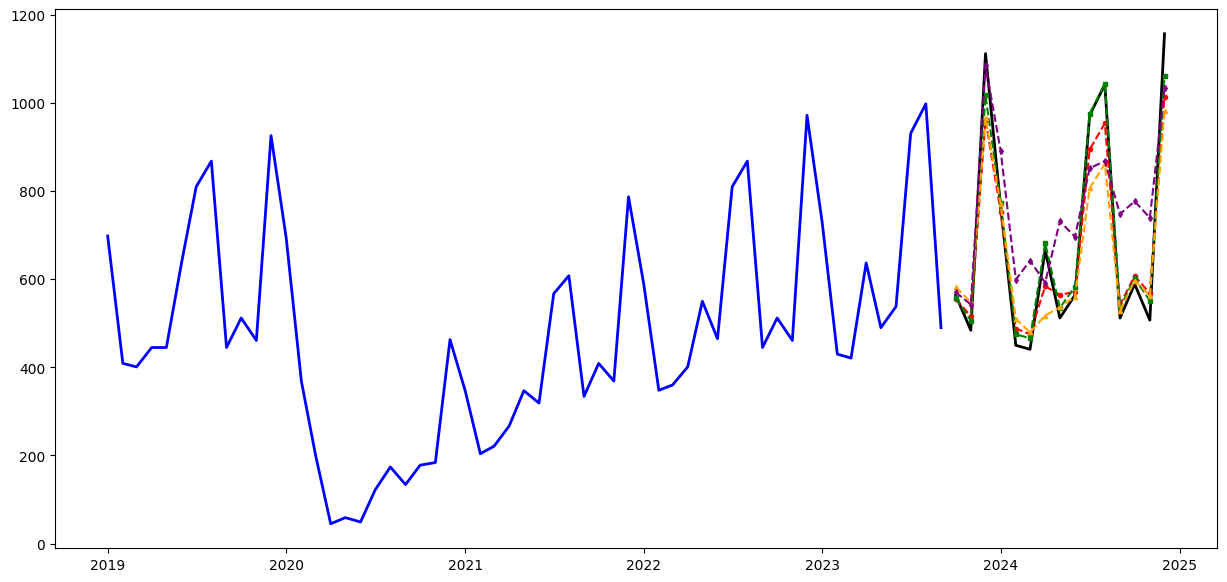

In [ ]:
# ================================================================
# KODE 5.6 - VISUALISASI PERBANDINGAN MODEL (DIPERBAIKI)
# ================================================================

print("\n" + "="*70)
print("VISUALISASI PERBANDINGAN MODEL")
print("="*70)

plt.figure(figsize=(15, 7))

# Plot data aktual
plt.plot(train_data['ds'], train_data['y'], label='Train Data (Aktual)', color='blue', linewidth=2)
plt.plot(test_data['ds'], test_data['y'], label='Test Data (Aktual)', color='black', linewidth=2)

# Plot semua model
plt.plot(test_data['ds'], forecast_arima[:len(test_data)],
         label='Auto ARIMA', color='red', linestyle='--', marker='o', markersize=3)
plt.plot(test_data['ds'], forecast_sarima[:len(test_data)],
         label='SARIMA', color='green', linestyle='--', marker='s', markersize=3)
plt.plot(test_data['ds'], forecast_ets[:len(test_data)],
         label='Exponential Smoothing', color='orange', linestyle='--', marker='^', markersize=3)
plt.plot(test_data['ds'], forecast_prophet_test[:len(test_data)],
         label='Prophet', color='purple', linestyle='--', marker='d', markersize=3)

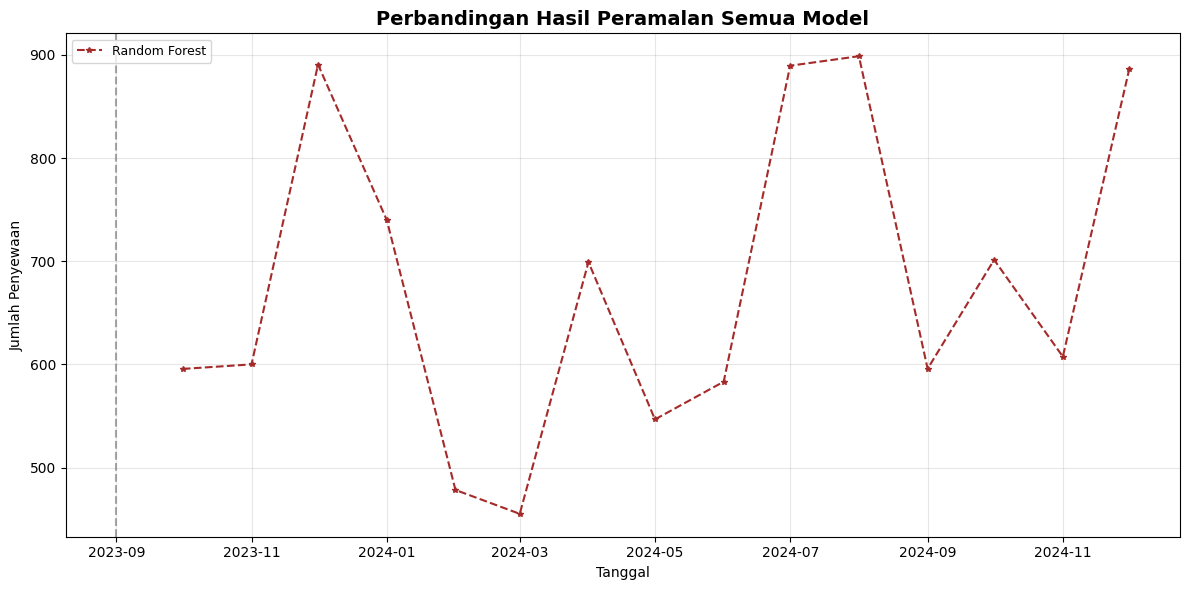

✅ Visualisasi berhasil dibuat!


In [ ]:
# ================================================================
# PERBAIKAN: RANDOM FOREST DENGAN RESET INDEX
# ================================================================

# Reset index untuk sinkronisasi
test_data_reset = test_data.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

# Plot Random Forest dengan data yang sudah direset
rf_test_dates = test_data_reset['ds'].iloc[X_test_reset.index]
plt.plot(rf_test_dates, forecast_rf,
         label='Random Forest', color='brown', linestyle='--', marker='*', markersize=4)

# Garis pemisah train-test
plt.axvline(x=train_data['ds'].iloc[-1], color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Styling
plt.title('Perbandingan Hasil Peramalan Semua Model', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Visualisasi berhasil dibuat!")

In [ ]:
# ================================================================
# KODE 6.1 - PERHITUNGAN METRIK EVALUASI
# ================================================================

def calculate_metrics(actual, predicted, model_name='Model'):
    mask = ~np.isnan(predicted) & ~np.isnan(actual)
    actual_clean = actual[mask]
    predicted_clean = predicted[mask]

    if len(actual_clean) == 0:
        return {'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}

    mae = mean_absolute_error(actual_clean, predicted_clean)
    mse = mean_squared_error(actual_clean, predicted_clean)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual_clean, predicted_clean) * 100

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

y_test_actual = test_data['y'].values

models = {
    'Auto ARIMA': forecast_arima,
    'SARIMA': forecast_sarima,
    'Exponential Smoothing': forecast_ets,
    'Prophet': forecast_prophet_test,
}

results = {}
for name, pred in models.items():
    pred_trim = pred[:len(y_test_actual)]
    results[name] = calculate_metrics(y_test_actual, pred_trim, name)

y_test_rf = y_test.values
results['Random Forest'] = calculate_metrics(y_test_rf, forecast_rf, 'Random Forest')

print("\n" + "="*70)
print("HASIL EVALUASI MODEL")
print("="*70)
print("\nPerbandingan Metrik Error:")

df_results = pd.DataFrame(results).T
df_results = df_results.round(2)
print(df_results)

best_rmse = df_results['RMSE'].min()
best_model = df_results[df_results['RMSE'] == best_rmse].index[0]
print(f"\n✅ Model dengan RMSE terbaik: {best_model} (RMSE = {best_rmse:.2f})")



HASIL EVALUASI MODEL

Perbandingan Metrik Error:
                          MAE       MSE    RMSE   MAPE
Auto ARIMA              55.60   4995.38   70.68   7.54
SARIMA                  28.13   1582.00   39.77   4.08
Exponential Smoothing   74.04   9852.67   99.26   9.68
Prophet                137.86  23933.77  154.71  23.46
Random Forest           87.68  13189.77  114.85  11.88

✅ Model dengan RMSE terbaik: SARIMA (RMSE = 39.77)


In [ ]:
# ================================================================
# KODE 6.2 - ANALISIS RESIDUAL (DIPERBAIKI)
# ================================================================

print("\n" + "="*70)
print("ANALISIS RESIDUAL")
print("="*70)

# Pastikan residuals memiliki panjang yang sama
residuals = y_test_actual - forecast_sarima[:len(y_test_actual)]

# Cek panjang residuals
print(f"Panjang residuals: {len(residuals)}")
print(f"Panjang test_data: {len(test_data)}")


ANALISIS RESIDUAL
Panjang residuals: 15
Panjang test_data: 15


Panjang residuals setelah hapus NaN: 15


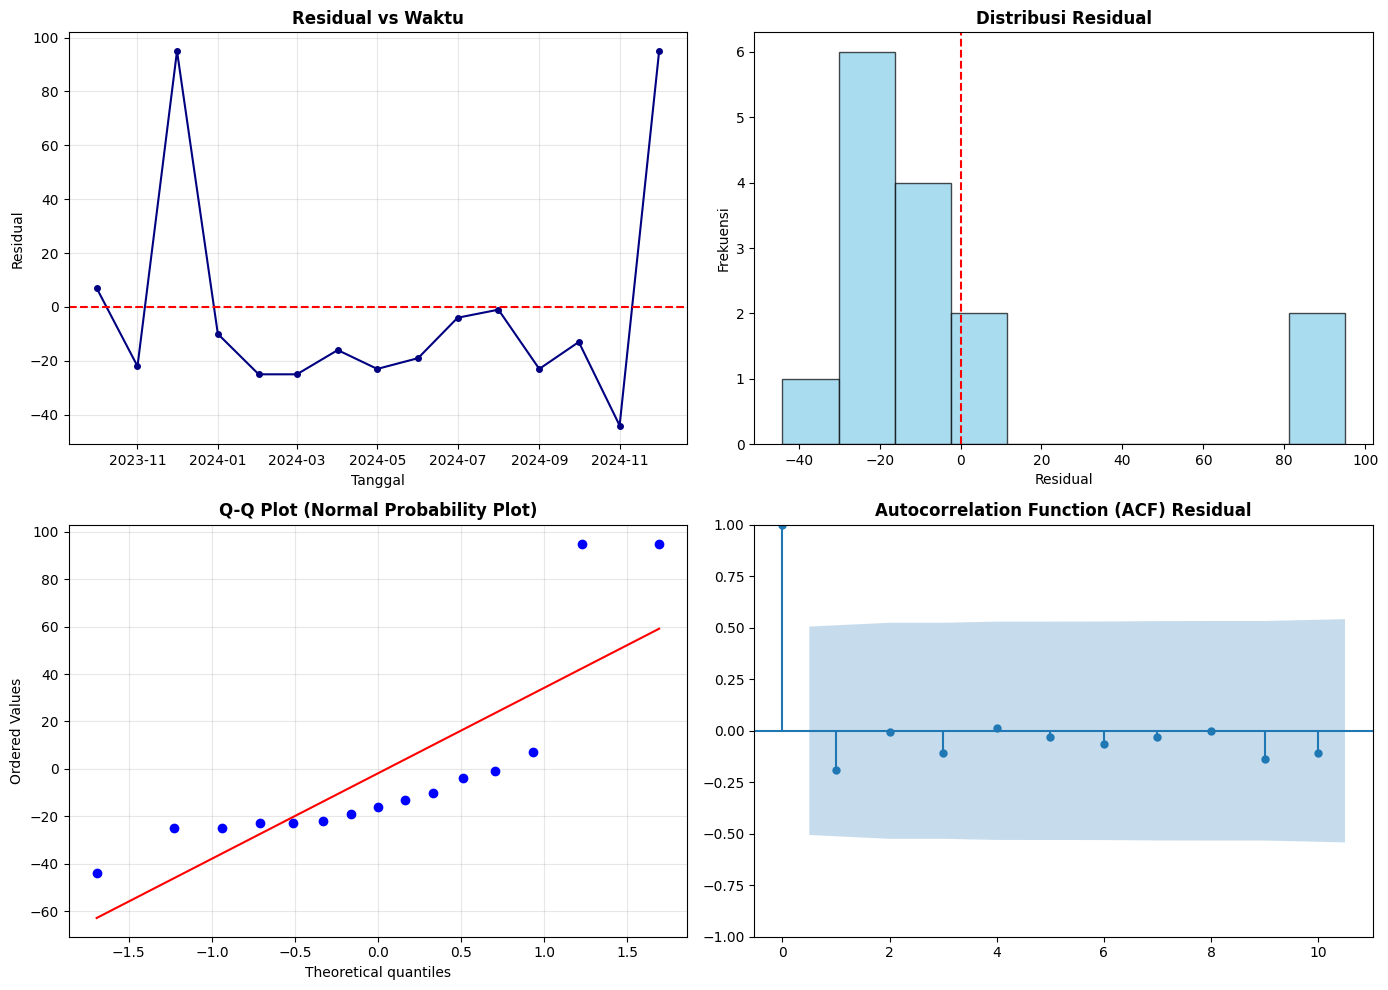

In [ ]:
# ================================================================
# PERBAIKAN 1: Gunakan residuals yang valid (tanpa NaN)
# ================================================================

# Hapus NaN jika ada
residuals_clean = residuals[~np.isnan(residuals)]
print(f"Panjang residuals setelah hapus NaN: {len(residuals_clean)}")

# Buat figure dengan 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residual vs Waktu (gunakan data yang bersih)
axes[0, 0].plot(test_data['ds'].iloc[:len(residuals_clean)], residuals_clean,
                marker='o', linestyle='-', color='navy', markersize=4)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residual vs Waktu', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tanggal')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram Residual
axes[0, 1].hist(residuals_clean, bins=min(10, len(residuals_clean)),
                edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--')
axes[0, 1].set_title('Distribusi Residual', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frekuensi')

# Plot 3: Q-Q Plot
from scipy import stats
stats.probplot(residuals_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Probability Plot)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: ACF Residual (DIPERBAIKI)
from statsmodels.graphics.tsaplots import plot_acf

# PERBAIKAN: Pastikan data memiliki panjang yang cukup
if len(residuals_clean) >= 5:
    plot_acf(residuals_clean, ax=axes[1, 1], lags=min(10, len(residuals_clean)-1))
    axes[1, 1].set_title('Autocorrelation Function (ACF) Residual', fontsize=12, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'Data terlalu pendek untuk ACF Plot',
                   ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('ACF Residual (Tidak dapat diplot)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ================================================================
# PERBAIKAN 2: Uji Ljung-Box dengan data yang bersih
# ================================================================

print("\n" + "="*70)
print("UJI LJUNG-BOX")
print("="*70)

from statsmodels.stats.diagnostic import acorr_ljungbox

# PERBAIKAN: Hanya jalankan jika data cukup
if len(residuals_clean) >= 5:
    lb_test = acorr_ljungbox(residuals_clean, lags=min(10, len(residuals_clean)-1), return_df=True)
    print("\nHasil Uji Ljung-Box (Residual white noise?):")
    print(lb_test)

    # Interpretasi
    if lb_test['lb_pvalue'].iloc[-1] > 0.05:
        print("\n✅ Residual adalah white noise (tidak ada autokorelasi)")
    else:
        print("\n❌ Residual BUKAN white noise (ada autokorelasi)")
else:
    print("⚠️ Data residual terlalu pendek untuk uji Ljung-Box")

print("\n✅ Analisis residual selesai!")


UJI LJUNG-BOX

Hasil Uji Ljung-Box (Residual white noise?):
     lb_stat  lb_pvalue
1   0.677380   0.410490
2   0.677692   0.712592
3   0.920881   0.820386
4   0.924807   0.920975
5   0.950380   0.966468
6   1.061854   0.983158
7   1.094808   0.993151
8   1.094814   0.997575
9   1.900011   0.992952
10  2.488495   0.991042

✅ Residual adalah white noise (tidak ada autokorelasi)

✅ Analisis residual selesai!



FORECASTING PERIODE MENDATANG (12 BULAN)
   Tanggal  Prediksi Penyewaan
2025-01-01                 557
2025-02-01                 506
2025-03-01                1017
2025-04-01                 774
2025-05-01                 475
2025-06-01                 466
2025-07-01                 682
2025-08-01                 535
2025-09-01                 583
2025-10-01                 976
2025-11-01                1043
2025-12-01                 535


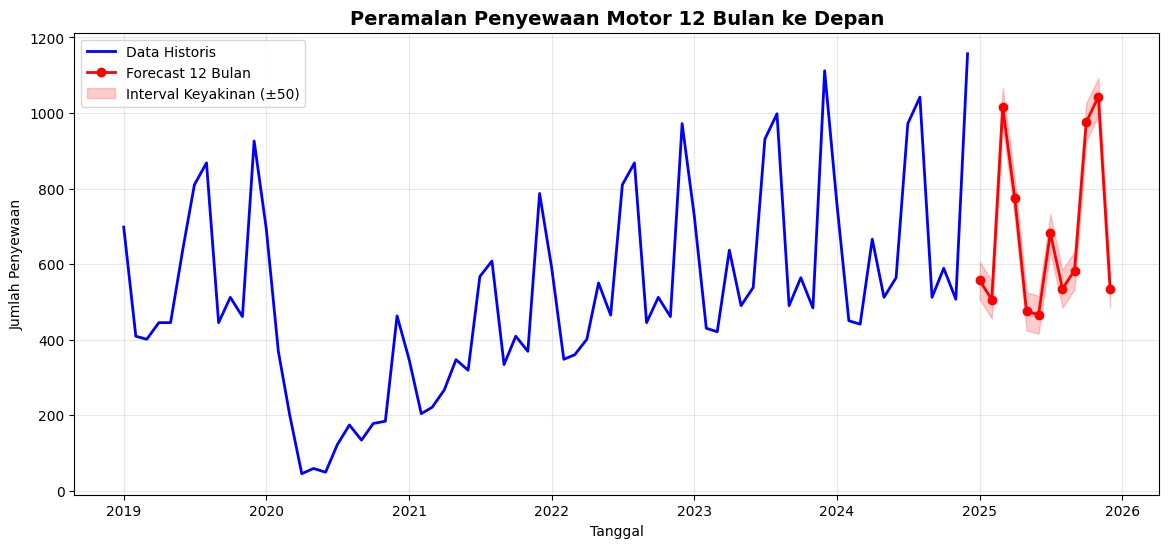


✅ Hasil forecast disimpan di 'forecast_12_bulan.csv'


In [ ]:
# ================================================================
# KODE 7.1 - FORECASTING PERIODE MENDATANG (12 BULAN)
# ================================================================

print("\n" + "="*70)
print("FORECASTING PERIODE MENDATANG (12 BULAN)")
print("="*70)

last_date = monthly_rental['ds'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')
future_forecast = result_sarima.forecast(steps=12)

forecast_table = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi Penyewaan': future_forecast
})
forecast_table['Prediksi Penyewaan'] = forecast_table['Prediksi Penyewaan'].round(0).astype(int)
print(forecast_table.to_string(index=False))

# Visualisasi forecast
plt.figure(figsize=(14, 6))
plt.plot(monthly_rental['ds'], monthly_rental['y'], label='Data Historis', color='blue', linewidth=2)
plt.plot(future_dates, future_forecast, label='Forecast 12 Bulan', color='red', linewidth=2, marker='o')
plt.fill_between(
    future_dates,
    future_forecast - 50,
    future_forecast + 50,
    color='red', alpha=0.2, label='Interval Keyakinan (±50)'
)
plt.title('Peramalan Penyewaan Motor 12 Bulan ke Depan', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

forecast_table.to_csv('forecast_12_bulan.csv', index=False)
print("\n✅ Hasil forecast disimpan di 'forecast_12_bulan.csv'")

In [ ]:
# ================================================================
# KODE 8.1 - SISTEM PREDIKSI UNTUK DEPLOYMENT
# ================================================================

def predict_rental(model, start_date, periods=12, conf_interval=0.95):
    forecast_result = model.get_forecast(steps=periods)
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int(alpha=1-conf_interval)

    future_dates = pd.date_range(start=start_date, periods=periods, freq='MS')

    result_df = pd.DataFrame({
        'Tanggal': future_dates,
        'Prediksi': forecast_mean.round(0).astype(int),
        'Lower_Bound': forecast_ci.iloc[:, 0].round(0).astype(int),
        'Upper_Bound': forecast_ci.iloc[:, 1].round(0).astype(int)
    })
    return result_df

start_date = monthly_rental['ds'].max() + pd.DateOffset(months=1)
prediction_result = predict_rental(result_sarima, start_date, periods=12, conf_interval=0.95)

print("\n" + "="*70)
print("HASIL PREDIKSI DENGAN INTERVAL KEPERCAYAAN 95%")
print("="*70)
print(prediction_result.to_string(index=False))

prediction_result.to_csv('deployment_prediction.csv', index=False)
print("\n✅ Hasil prediksi deployment disimpan di 'deployment_prediction.csv'")


HASIL PREDIKSI DENGAN INTERVAL KEPERCAYAAN 95%
   Tanggal  Prediksi  Lower_Bound  Upper_Bound
2025-01-01       557    -18063201     18064315
2025-02-01       506    -25545505     25546517
2025-03-01      1017    -31286329     31288363
2025-04-01       774    -36126741     36128289
2025-05-01       475    -40391315     40392265
2025-06-01       466    -44246523     44247455
2025-07-01       682    -47791529     47792893
2025-08-01       535    -51091487     51092557
2025-09-01       583    -54190690     54191856
2025-10-01       976    -57121642     57123594
2025-11-01      1043    -59909664     59911750
2025-12-01       535    -62574157     62575227

✅ Hasil prediksi deployment disimpan di 'deployment_prediction.csv'


In [ ]:
# ================================================================
# KODE 9.1 - EXPORT FILE UNTUK LAPORAN
# ================================================================

print("\n" + "="*70)
print("EKSPORT HASIL ANALISIS")
print("="*70)

monthly_rental.to_csv('data_agregasi_bulanan.csv', index=False)
print("✅ Data agregasi bulanan disimpan")

df_results.to_csv('hasil_evaluasi_model.csv')
print("✅ Hasil evaluasi model disimpan")

residual_df = pd.DataFrame({
    'Tanggal': test_data['ds'],
    'Aktual': y_test_actual,
    'Prediksi_SARIMA': forecast_sarima[:len(y_test_actual)],
    'Residual': residuals
})
residual_df.to_csv('analisis_residual.csv', index=False)
print("✅ Analisis residual disimpan")

best_params = {
    'Model': best_model,
    'RMSE': best_rmse,
    'Order': f'(p={p}, d={d}, q={q})',
    'Seasonal_Order': f'(P={P}, D={D}, Q={Q}, m={m})'
}
pd.DataFrame([best_params]).to_csv('model_terbaik.csv', index=False)
print("✅ Parameter model terbaik disimpan")

print("\n✅ Semua file untuk laporan telah disimpan!")
print("\nFile yang dihasilkan:")
print(" 1. data_agregasi_bulanan.csv")
print(" 2. hasil_evaluasi_model.csv")
print(" 3. analisis_residual.csv")
print(" 4. model_terbaik.csv")
print(" 5. forecast_12_bulan.csv")
print(" 6. deployment_prediction.csv")

print("\n" + "="*70)
print("🎉 PROSES FORECASTING SELESAI!")
print("="*70)
print(f"\n✅ Model terbaik: {best_model}")
print(f"✅ RMSE terbaik: {best_rmse:.2f}")
print(f"✅ Jumlah data: {len(monthly_rental)} bulan")
print(f"✅ Train-Test: {len(train_data)}-{len(test_data)} bulan")
print("\nSilakan download file-file di atas untuk laporan Anda.")


EKSPORT HASIL ANALISIS
✅ Data agregasi bulanan disimpan
✅ Hasil evaluasi model disimpan
✅ Analisis residual disimpan
✅ Parameter model terbaik disimpan

✅ Semua file untuk laporan telah disimpan!

File yang dihasilkan:
 1. data_agregasi_bulanan.csv
 2. hasil_evaluasi_model.csv
 3. analisis_residual.csv
 4. model_terbaik.csv
 5. forecast_12_bulan.csv
 6. deployment_prediction.csv

🎉 PROSES FORECASTING SELESAI!

✅ Model terbaik: SARIMA
✅ RMSE terbaik: 39.77
✅ Jumlah data: 72 bulan
✅ Train-Test: 57-15 bulan

Silakan download file-file di atas untuk laporan Anda.
